# Benchmark - [Meta's Muse Glimmer 30B](https://huggingface.co/unsloth/Muse-Glimmer-30B-GGUF)

**Date:** 11-16 Aug 2026

**Evaluation:** Tasks 01-07

**Hardware:** Apple M3 Max 36GB

**Quantization:** UD-Q4_K_XL

In [1]:
import pandas as pd
from matplotlib import pyplot as plt

from benchmark_lib import (
  DATA_DIR,
  add_token_counts,
  compare_skills,
  latest_batches,
  load_runs,
  metric_table,
  plot_benchmark,
  plot_skill_summary,
  plot_timeouts,
  save_runs,
)

HARDWARE = "Apple M3 Max 36GB"
MODEL_LABEL = "Muse Glimmer 30B"


In [2]:
MODEL_NAME = "Muse-Glimmer-30B-Q4_K_XL"
benchmark_dir = DATA_DIR / "meta" / "muse-glimmer-30b"

if (not (benchmark_dir / "benchmark.csv").exists()):
  all_runs = load_runs(model=MODEL_NAME, hardware=HARDWARE)
  df = add_token_counts(latest_batches(all_runs))
  save_runs(df, benchmark_dir)


In [3]:
benchmark = pd.read_csv(benchmark_dir / "benchmark.csv")
benchmark["start_time"] = pd.to_datetime(benchmark["start_time"])
benchmark


,task,run,start_time,skills,score,points,total,passed,structure_match,duration_seconds,...,model,harness,model_server,hardware,fields,input_tokens,output_tokens,cache_read_tokens,cache_write_tokens,total_tokens
0,01-data-loading,20260812_004106,2026-08-12 00:41:06.411472,False,1.000000,5.000000,5,True,True,1259,...,Muse-Glimmer-30B-Q4_K_XL,pi,llama.cpp,Apple M3 Max 36GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",14831,11803,432339,0,458973
1,01-data-loading,20260812_010206,2026-08-12 01:02:06.670934,False,1.000000,5.000000,5,True,True,1894,...,Muse-Glimmer-30B-Q4_K_XL,pi,llama.cpp,Apple M3 Max 36GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",11543,18466,727489,0,757498
2,01-data-loading,20260812_013342,2026-08-12 01:33:42.643718,False,1.000000,5.000000,5,True,True,1357,...,Muse-Glimmer-30B-Q4_K_XL,pi,llama.cpp,Apple M3 Max 36GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",9324,13206,722060,0,744590
3,01-data-loading,20260812_015620,2026-08-12 01:56:20.946868,False,1.000000,5.000000,5,True,True,1515,...,Muse-Glimmer-30B-Q4_K_XL,pi,llama.cpp,Apple M3 Max 36GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",13390,13742,722563,0,749695
4,01-data-loading,20260812_022137,2026-08-12 02:21:37.235179,False,1.000000,5.000000,5,True,True,1226,...,Muse-Glimmer-30B-Q4_K_XL,pi,llama.cpp,Apple M3 Max 36GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",7592,11729,475088,0,494409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,07-epitope-databases,20260815_234938_1,2026-08-15 23:49:38.556058,True,1.000000,3.000000,3,True,True,1959,...,Muse-Glimmer-30B-Q4_K_XL,pi,llama.cpp,Apple M3 Max 36GB,{'top_antigen_species_normal': {'expected': 'S...,28789,14645,595978,0,639412
66,07-epitope-databases,20260816_002218_2,2026-08-16 00:22:18.437349,True,1.000000,3.000000,3,True,True,3600,...,Muse-Glimmer-30B-Q4_K_XL,pi,llama.cpp,Apple M3 Max 36GB,{'top_antigen_species_normal': {'expected': 'S...,35855,27117,1641277,0,1704249
67,07-epitope-databases,20260816_012218_3,2026-08-16 01:22:18.847394,True,1.000000,3.000000,3,True,True,2475,...,Muse-Glimmer-30B-Q4_K_XL,pi,llama.cpp,Apple M3 Max 36GB,{'top_antigen_species_normal': {'expected': 'S...,33830,17688,838165,0,889683
68,07-epitope-databases,20260816_020334_4,2026-08-16 02:03:34.049033,True,0.777778,2.333333,3,False,True,3152,...,Muse-Glimmer-30B-Q4_K_XL,pi,llama.cpp,Apple M3 Max 36GB,{'top_antigen_species_normal': {'expected': 'S...,36787,23536,1910980,0,1971303


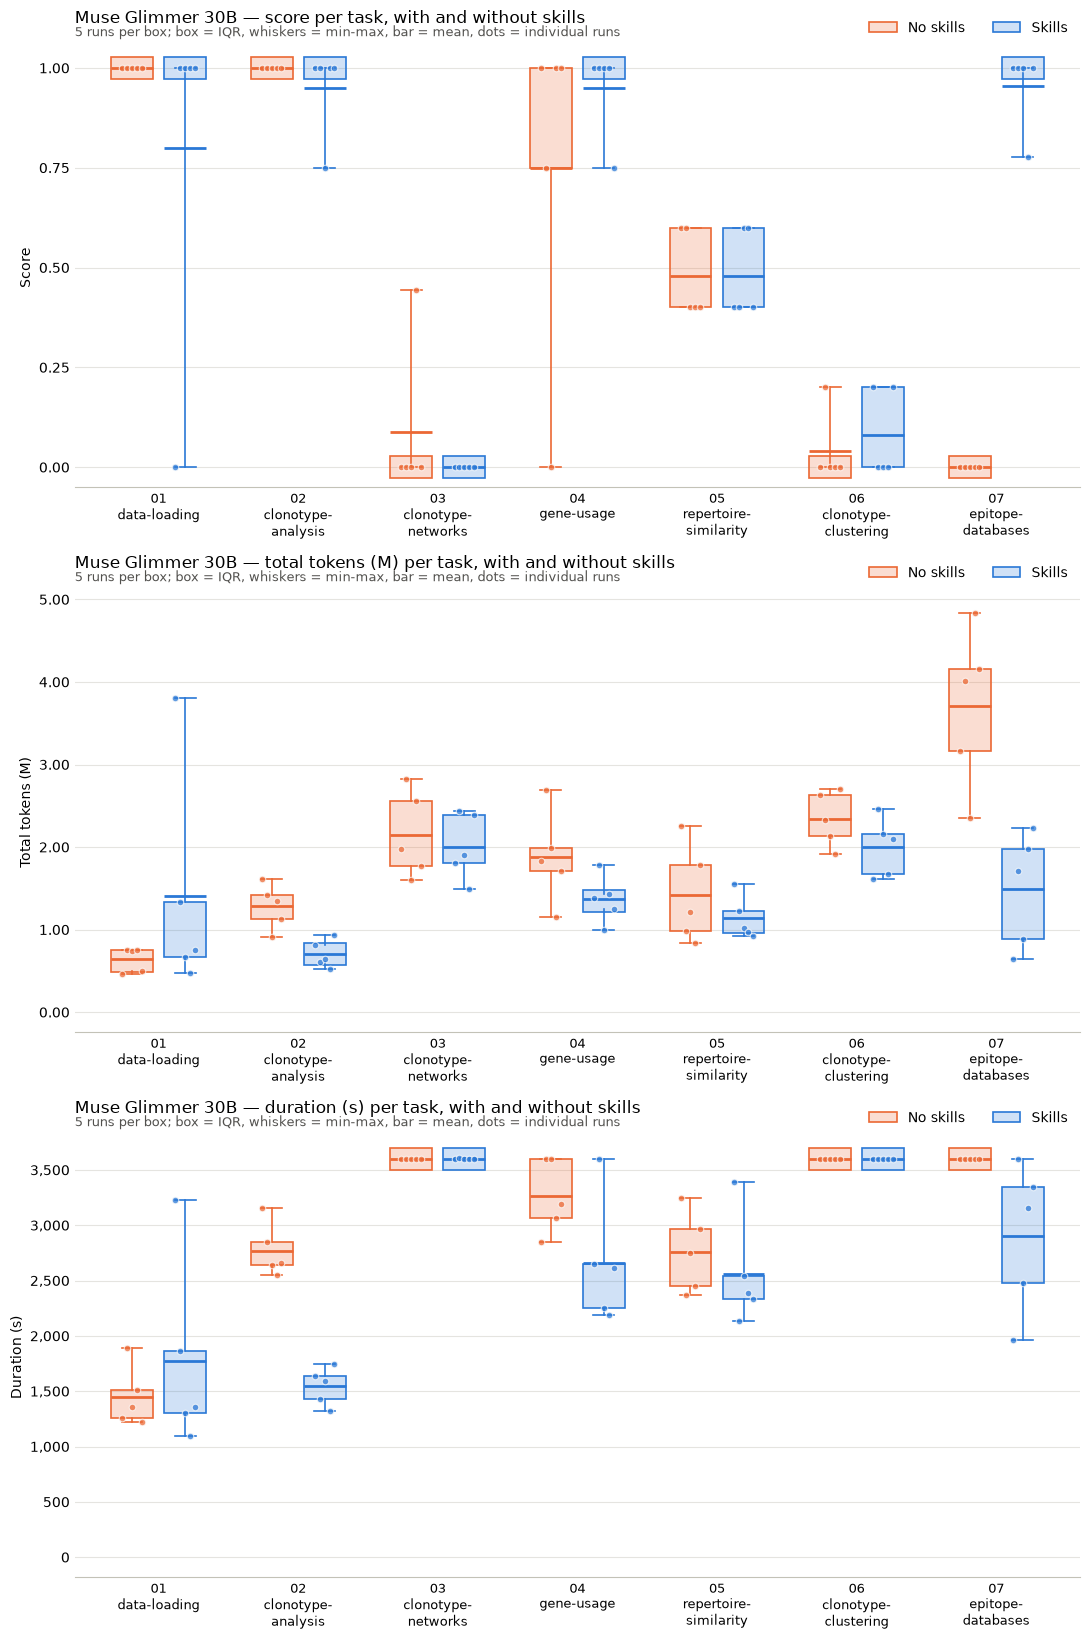

In [4]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(11, 5.5 * 3))
plot_benchmark(benchmark, column="score", model_label=MODEL_LABEL, ax=axs[0])
plot_benchmark(benchmark, column="total_tokens", model_label=MODEL_LABEL, ax=axs[1])
plot_benchmark(benchmark, column="duration_seconds", model_label=MODEL_LABEL, ax=axs[2])
fig.tight_layout()
plt.show()


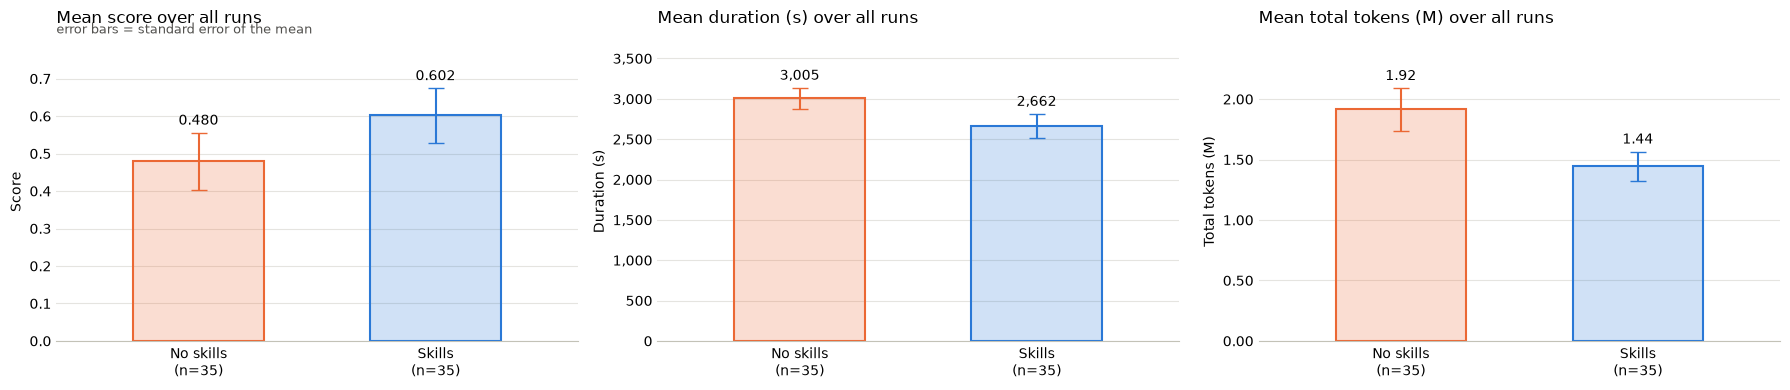

In [5]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(6 * 3, 4))
plot_skill_summary(benchmark, axs=axs)
fig.tight_layout()
plt.show()


In [6]:
significance = compare_skills(benchmark)


In [7]:
metric_table(significance, "score")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,35 vs 35,0.479841,0.602222,0.122381,0.265833,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,1.000000,0.800000,-0.200000,0.423711,0.700550,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,1.000000,0.950000,-0.050000,0.423711,0.700550,False
3,03-clonotype-networks,Mann-Whitney U,5 vs 5,0.088889,0.000000,-0.088889,0.423711,0.700550,False
4,04-gene-usage,Mann-Whitney U,5 vs 5,0.750000,0.950000,0.200000,0.518605,0.700550,False
5,05-repertoire-similarity,Mann-Whitney U,5 vs 5,0.480000,0.480000,0.000000,1.000000,1.000000,False
6,06-clonotype-clustering,Mann-Whitney U,5 vs 5,0.040000,0.080000,0.040000,0.600471,0.700550,False
7,07-epitope-databases,Mann-Whitney U,5 vs 5,0.000000,0.955556,0.955556,0.005584,0.039085,True
8,all tasks (paired by task),Wilcoxon signed-rank,7 tasks,0.479841,0.602222,0.122381,0.875000,NaN,False


In [8]:
metric_table(significance, "duration_seconds")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,35 vs 35,3005.285714,2662.371429,-342.914286,0.115903,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,1450.200000,1769.600000,319.400000,0.841270,0.981481,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,2769.200000,1544.600000,-1224.600000,0.007937,0.055556,False
3,03-clonotype-networks,Mann-Whitney U,5 vs 5,3600.000000,3601.600000,1.600000,0.423711,0.593195,False
4,04-gene-usage,Mann-Whitney U,5 vs 5,3261.400000,2658.200000,-603.200000,0.090688,0.211606,False
5,05-repertoire-similarity,Mann-Whitney U,5 vs 5,2756.200000,2556.000000,-200.200000,0.420635,0.593195,False
6,06-clonotype-clustering,Mann-Whitney U,5 vs 5,3600.000000,3600.000000,0.000000,1.000000,1.000000,False
7,07-epitope-databases,Mann-Whitney U,5 vs 5,3600.000000,2906.600000,-693.400000,0.025370,0.088795,False
8,all tasks (paired by task),Wilcoxon signed-rank,7 tasks,3005.285714,2662.371429,-342.914286,0.218750,NaN,False


In [9]:
metric_table(significance, "total_tokens")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,35 vs 35,1.916056e+06,1.444403e+06,-471653.0,0.047135,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,6.410330e+05,1.409414e+06,768381.4,0.420635,0.588889,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,1.286197e+06,7.027446e+05,-583452.2,0.015873,0.055556,False
3,03-clonotype-networks,Mann-Whitney U,5 vs 5,2.145494e+06,2.005013e+06,-140480.6,0.690476,0.690476,False
4,04-gene-usage,Mann-Whitney U,5 vs 5,1.877439e+06,1.367972e+06,-509467.4,0.150794,0.351852,False
5,05-repertoire-similarity,Mann-Whitney U,5 vs 5,1.414203e+06,1.139386e+06,-274817.0,0.690476,0.690476,False
6,06-clonotype-clustering,Mann-Whitney U,5 vs 5,2.343688e+06,1.998578e+06,-345109.8,0.222222,0.388889,False
7,07-epitope-databases,Mann-Whitney U,5 vs 5,3.704337e+06,1.487712e+06,-2216625.4,0.007937,0.055556,False
8,all tasks (paired by task),Wilcoxon signed-rank,7 tasks,1.916056e+06,1.444403e+06,-471653.0,0.218750,NaN,False


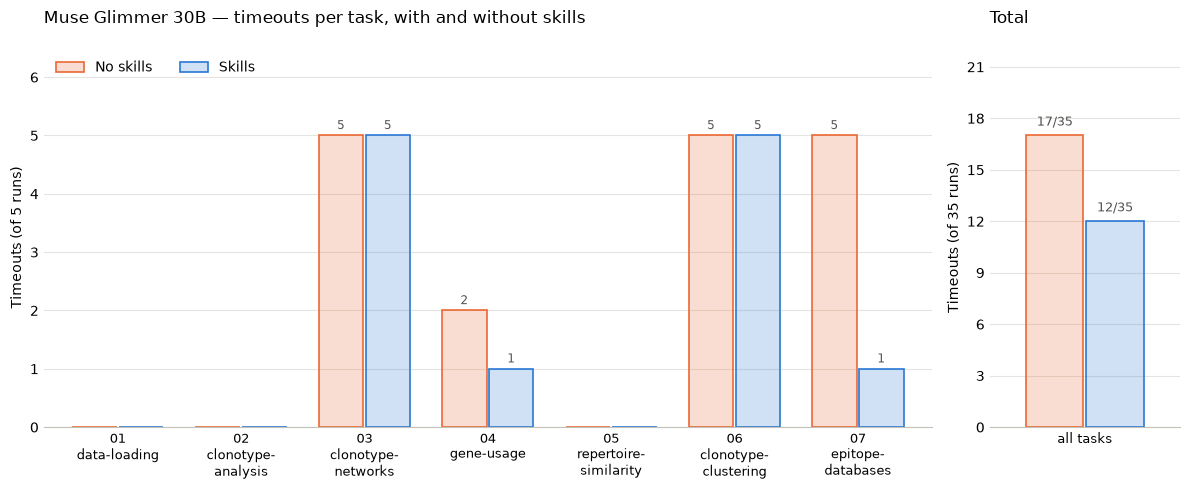

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [7, 1.5]})
plot_timeouts(benchmark, model_label=MODEL_LABEL, axs=axs)
fig.tight_layout()
plt.show()
